<a href="https://colab.research.google.com/github/gulzhanmsc/IB9AU/blob/main/Gen_AI_Task_13_18.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Key insights:

Through this task I learned how to generate synthetic tabular data using two different approaches CTGAN and TVAE, and understood the fundamental difference between adversarial and variational training. More importantly, I learned that generating synthetic data is only half the problem; evaluating its quality rigorously using the fidelity-utility-privacy framework is equally critical. KS tests, TSTR, and nearest-neighbour distances gave me a structured way to measure whether synthetic fraud records are actually trustworthy, rather than just visually plausible.

In [18]:
!pip install sdv ctgan scikit-learn scipy pandas numpy matplotlib seaborn

In [19]:
# Import
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from ctgan import CTGAN
from sdv.single_table import TVAESynthesizer
from sdv.metadata import SingleTableMetadata

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, f1_score
from sklearn.neighbors import NearestNeighbors
from scipy.stats import ks_2samp

print('All libraries imported.')

All libraries imported.


Load and Explore fraud_transactions.csv

In [20]:
# Optional: mount Google Drive (Colab only)
try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [21]:
# Set path to your CSV

CSV_PATH = '/content/drive/MyDrive/Gen AI Data/fraud_transactions.csv'

df = pd.read_csv(CSV_PATH)
print(f'Loaded {df.shape[0]:,} rows × {df.shape[1]} columns')
df.head()

Loaded 6,486 rows × 8 columns


,trans_date_trans_time,merchant,category,amt,gender,state,job,is_fraud
0,2/27/19 21:32,"fraud_Langosh, Wintheiser and Hyatt",food_dining,83.64,F,TX,"Physicist, medical",0
1,2/13/19 19:41,fraud_Dibbert and Sons,entertainment,79.13,M,PA,Secretary/administrator,0
2,1/11/19 20:03,"fraud_McDermott, Osinski and Morar",home,12.02,F,CA,"Buyer, industrial",0
3,1/20/19 9:08,fraud_Bauch-Raynor,grocery_pos,84.41,M,TN,Clothing/textile technologist,0
4,1/4/19 17:04,"fraud_Reichert, Huels and Hoppe",shopping_net,2.81,F,ME,Financial trader,0


In [22]:
# Schema and basic stats
df.info()
print('\nMissing values:')
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6486 entries, 0 to 6485
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   trans_date_trans_time  6486 non-null   object 
 1   merchant               6486 non-null   object 
 2   category               6486 non-null   object 
 3   amt                    6486 non-null   float64
 4   gender                 6486 non-null   object 
 5   state                  6486 non-null   object 
 6   job                    6486 non-null   object 
 7   is_fraud               6486 non-null   int64  
dtypes: float64(1), int64(1), object(6)
memory usage: 405.5+ KB

Missing values:
trans_date_trans_time    0
merchant                 0
category                 0
amt                      0
gender                   0
state                    0
job                      0
is_fraud                 0
dtype: int64


In [23]:
df.describe(include='all')

,trans_date_trans_time,merchant,category,amt,gender,state,job,is_fraud
count,6486,6486,6486,6486.000000,6486,6486,6486,6486.000000
unique,6191,692,14,NaN,2,50,472,NaN
top,2/24/19 10:39,fraud_Goodwin-Nitzsche,gas_transport,NaN,F,TX,"Surveyor, land/geomatics",NaN
freq,3,23,691,NaN,3590,462,51,NaN
mean,NaN,NaN,NaN,101.700956,NaN,NaN,NaN,0.074931
std,NaN,NaN,NaN,189.292632,NaN,NaN,NaN,0.263300
min,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,0.000000
25%,NaN,NaN,NaN,12.572500,NaN,NaN,NaN,0.000000
50%,NaN,NaN,NaN,52.080000,NaN,NaN,NaN,0.000000
75%,NaN,NaN,NaN,91.945000,NaN,NaN,NaN,0.000000


In [24]:
# Identify column types automatically
# We auto-detect:
#   target_col   – binary fraud indicator (look for 'fraud', 'is_fraud', 'label', 'Class')
#   cat_cols     – object dtype or low-cardinality int columns
#   num_cols     – remaining numeric columns
#
# If auto-detection picks the wrong column, override manually below.

# --- Auto-detect target column ---
fraud_keywords = ['fraud', 'is_fraud', 'isFraud', 'label', 'Label', 'Class', 'class', 'target']
target_col = None
for kw in fraud_keywords:
    matches = [c for c in df.columns if kw.lower() in c.lower()]
    if matches:
        target_col = matches[0]
        break

if target_col is None:
    raise ValueError(
        "Could not auto-detect target column. "
        "Please set target_col manually, e.g.: target_col = 'fraud'"
    )

print(f'Target column : {target_col}')
print(f'Class balance :\n{df[target_col].value_counts(normalize=True)}\n')

# --- Separate feature columns ---
feature_cols = [c for c in df.columns if c != target_col]

# Columns to DROP from modelling (IDs, timestamps with too many unique values)
drop_keywords = ['id', 'ID', 'trans_date', 'trans_time', 'unix', 'first', 'last',
                 'street', 'city', 'zip', 'dob', 'trans_num', 'merchant', 'cc_num']
drop_cols = [c for c in feature_cols
             if any(kw.lower() in c.lower() for kw in drop_keywords)
             or (df[c].dtype == object and df[c].nunique() > 50)]

feature_cols = [c for c in feature_cols if c not in drop_cols]
print(f'Dropped high-cardinality/ID cols: {drop_cols}')

# Categorical vs numeric
cat_cols = [c for c in feature_cols
            if df[c].dtype == object
            or (df[c].dtype in ['int64', 'int32'] and df[c].nunique() <= 20 and c != target_col)]
num_cols = [c for c in feature_cols if c not in cat_cols]

print(f'Categorical features ({len(cat_cols)}): {cat_cols}')
print(f'Numeric features    ({len(num_cols)}): {num_cols}')

Target column : is_fraud
Class balance :
is_fraud
0    0.925069
1    0.074931
Name: proportion, dtype: float64

Dropped high-cardinality/ID cols: ['trans_date_trans_time', 'merchant', 'job']
Categorical features (3): ['category', 'gender', 'state']
Numeric features    (1): ['amt']


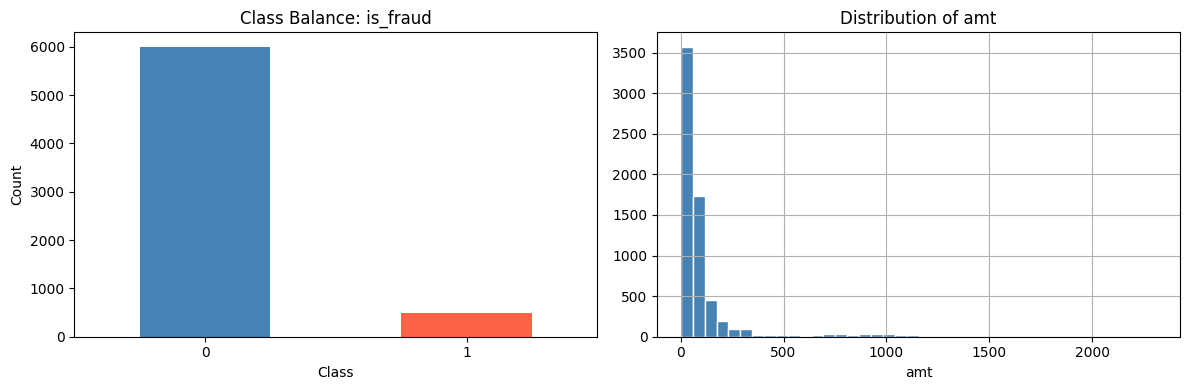

In [25]:
# Class imbalance & numeric distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Class balance bar chart
df[target_col].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue', 'tomato'])
axes[0].set_title(f'Class Balance: {target_col}')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

# Distribution of first numeric feature as a sample
if num_cols:
    df[num_cols[0]].hist(bins=40, ax=axes[1], color='steelblue', edgecolor='white')
    axes[1].set_title(f'Distribution of {num_cols[0]}')
    axes[1].set_xlabel(num_cols[0])

plt.tight_layout()
plt.show()

# Correlation heatmap on numeric features
if len(num_cols) >= 2:
    plt.figure(figsize=(min(14, len(num_cols)), min(10, len(num_cols))))
    sns.heatmap(df[num_cols].corr(), annot=len(num_cols) <= 10,
                fmt='.2f', cmap='coolwarm', linewidths=0.5)
    plt.title('Real Data — Numeric Feature Correlations')
    plt.tight_layout()
    plt.show()

Pre-processing & Train/Test Split

In [26]:
# Keep only the columns we will use, drop NAs
model_cols = cat_cols + num_cols + [target_col]
df_clean = df[model_cols].dropna().reset_index(drop=True)

# Ensure target is integer 0/1
df_clean[target_col] = df_clean[target_col].astype(int)

print(f'Clean dataset: {df_clean.shape[0]:,} rows')
print(f'Fraud rate   : {df_clean[target_col].mean():.3%}')

# Stratified train/test split
real_train, real_test = train_test_split(
    df_clean,
    test_size=0.2,
    random_state=42,
    stratify=df_clean[target_col]
)
print(f'Train: {len(real_train):,}  |  Test: {len(real_test):,}')

Clean dataset: 6,486 rows
Fraud rate   : 7.493%
Train: 5,188  |  Test: 1,298


In [27]:
# Fit encoders on REAL TRAINING DATA ONLY
# (same discipline as the lab notebook — never leak test/synthetic info into the encoder)

ohe    = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
scaler = StandardScaler()

if cat_cols:
    ohe.fit(real_train[cat_cols])
scaler.fit(real_train[num_cols])

def preprocess_for_model(df_subset):
    """Return (X_array, y_series) ready for sklearn models."""
    y_out  = df_subset[target_col].astype(int)
    X_num  = scaler.transform(df_subset[num_cols])
    if cat_cols:
        X_cat = ohe.transform(df_subset[cat_cols])
        X_all = np.hstack([X_cat, X_num])
    else:
        X_all = X_num
    return X_all, y_out

print('Preprocessor fitted on real training data.')

Preprocessor fitted on real training data.


Train CTGAN and Generate 5,000 Synthetic Records

In [28]:
# Discrete columns = categoricals + integer count columns + target
int_count_cols = [c for c in num_cols if df_clean[c].dtype in ['int64','int32']
                  and df_clean[c].nunique() <= 30]
discrete_cols  = cat_cols + int_count_cols + [target_col]

ctgan_data = df_clean[model_cols].copy()

ctgan = CTGAN(
    epochs=300,
    batch_size=500,
    verbose=True
)
ctgan.fit(ctgan_data, discrete_columns=discrete_cols)
print('\nCTGAN training complete.')

Gen. (-00.37) | Discrim. (+00.00): 100%|██████████| 300/300 [05:53<00:00,  1.18s/it]


CTGAN training complete.


In [29]:
N_SYNTH = 5000

synthetic_ctgan = ctgan.sample(N_SYNTH)
synthetic_ctgan[target_col] = synthetic_ctgan[target_col].astype(int)

print(f'Generated {len(synthetic_ctgan):,} synthetic records.')
print('\nCTGAN synthetic fraud rate:')
print(synthetic_ctgan[target_col].value_counts(normalize=True))
synthetic_ctgan.head()

Generated 5,000 synthetic records.

CTGAN synthetic fraud rate:
is_fraud
0    0.8242
1    0.1758
Name: proportion, dtype: float64


,category,gender,state,amt,is_fraud
0,shopping_pos,F,OH,3.783938,0
1,gas_transport,M,IN,84.050127,0
2,gas_transport,M,CA,86.250923,0
3,home,F,MT,13.862135,0
4,home,F,TX,4.969536,0


Train TVAE and Generate 5,000 Synthetic Records

In [30]:
tvae_data = df_clean[model_cols].copy()

metadata = SingleTableMetadata()
metadata.detect_from_dataframe(tvae_data)

# Override detected types for discrete columns
for col in discrete_cols:
    metadata.update_column(column_name=col, sdtype='categorical')

tvae = TVAESynthesizer(
    metadata=metadata,
    epochs=300,
    batch_size=500
)
tvae.fit(tvae_data)
print('\nTVAE training complete.')


TVAE training complete.


In [31]:
synthetic_tvae = tvae.sample(N_SYNTH)
synthetic_tvae[target_col] = synthetic_tvae[target_col].astype(int)

print(f'Generated {len(synthetic_tvae):,} synthetic records.')
print('\nTVAE synthetic fraud rate:')
print(synthetic_tvae[target_col].value_counts(normalize=True))
synthetic_tvae.head()

Generated 5,000 synthetic records.

TVAE synthetic fraud rate:
is_fraud
0    0.938
1    0.062
Name: proportion, dtype: float64


,category,gender,state,amt,is_fraud
0,shopping_pos,M,AL,2.97,0
1,kids_pets,F,KY,24.09,1
2,food_dining,M,CA,115.58,0
3,home,M,NJ,98.75,0
4,shopping_net,M,ME,6.45,1


Fidelity — KS Test (Univariate)

KS statistics per numeric feature (lower = better fidelity):
     KS_CTGAN  KS_TVAE
amt    0.0998   0.0486


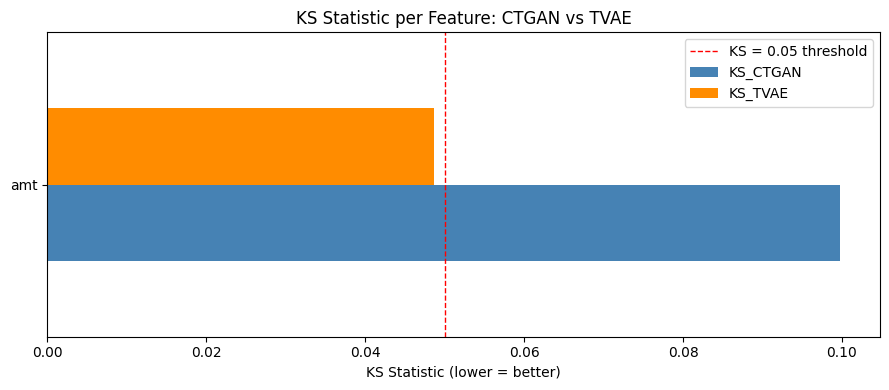

In [32]:
def ks_per_feature(real_df, syn_df, cols):
    results = {}
    for col in cols:
        r = real_df[col].sample(min(5000, len(real_df)), random_state=42)
        s = syn_df[col].sample(min(5000, len(syn_df)), random_state=42)
        stat, pval = ks_2samp(r, s)
        results[col] = {'ks_stat': round(stat, 4), 'p_value': round(pval, 4)}
    return pd.DataFrame(results).T

real_all = df_clean.copy()
ks_ctgan = ks_per_feature(real_all, synthetic_ctgan, num_cols)
ks_tvae  = ks_per_feature(real_all, synthetic_tvae,  num_cols)

ks_compare = pd.DataFrame({
    'KS_CTGAN': ks_ctgan['ks_stat'],
    'KS_TVAE' : ks_tvae['ks_stat']
}).sort_values('KS_CTGAN')

print('KS statistics per numeric feature (lower = better fidelity):')
print(ks_compare.to_string())

# Plot
ks_compare.plot(kind='barh', figsize=(9, max(4, len(num_cols)*0.4)),
                color=['steelblue', 'darkorange'])
plt.axvline(0.05, color='red', linestyle='--', linewidth=1, label='KS = 0.05 threshold')
plt.title('KS Statistic per Feature: CTGAN vs TVAE')
plt.xlabel('KS Statistic (lower = better)')
plt.legend()
plt.tight_layout()
plt.show()

Fidelity — Correlation Structure

In [33]:
if len(num_cols) >= 2:
    real_corr  = real_all[num_cols].corr()
    ctgan_corr = synthetic_ctgan[num_cols].corr()
    tvae_corr  = synthetic_tvae[num_cols].corr()

    ctgan_diff = (real_corr - ctgan_corr).abs()
    tvae_diff  = (real_corr - tvae_corr).abs()

    corr_compare = pd.DataFrame({
        'Mean |Δcorr| CTGAN': ctgan_diff.mean(),
        'Mean |Δcorr| TVAE' : tvae_diff.mean()
    }).sort_values('Mean |Δcorr| CTGAN')

    print('Mean absolute correlation difference per feature (lower = better):')
    print(corr_compare.to_string())

    # Heatmaps side-by-side
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    kw = dict(annot=len(num_cols)<=8, fmt='.2f', cmap='coolwarm',
              vmin=-1, vmax=1, linewidths=0.3)
    sns.heatmap(real_corr,  ax=axes[0], **kw); axes[0].set_title('Real')
    sns.heatmap(ctgan_corr, ax=axes[1], **kw); axes[1].set_title('CTGAN Synthetic')
    sns.heatmap(tvae_corr,  ax=axes[2], **kw); axes[2].set_title('TVAE Synthetic')
    plt.suptitle('Pairwise Correlation Matrices', fontsize=13)
    plt.tight_layout()
    plt.show()
else:
    print('Not enough numeric columns for correlation analysis.')

Not enough numeric columns for correlation analysis.


Utility — Train-Synthetic-Test-Real (TSTR)

In [34]:
# ── TRTR baseline ─────────────────────────────────────────────────────────────
X_real_train, y_real_train = preprocess_for_model(real_train)
X_real_test,  y_real_test  = preprocess_for_model(real_test)

rf_real = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
rf_real.fit(X_real_train, y_real_train)

y_prob_real = rf_real.predict_proba(X_real_test)[:, 1]
y_pred_real = (y_prob_real >= 0.5).astype(int)

auc_real = roc_auc_score(y_real_test, y_prob_real)
f1_real  = f1_score(y_real_test, y_pred_real, zero_division=0)
print(f'TRTR  →  AUC: {auc_real:.4f}  |  F1: {f1_real:.4f}')

TRTR  →  AUC: 0.9905  |  F1: 0.8404


In [35]:
# ── TSTR — CTGAN ──────────────────────────────────────────────────────────────
X_ctgan_train, y_ctgan_train = preprocess_for_model(synthetic_ctgan)

rf_ctgan = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
rf_ctgan.fit(X_ctgan_train, y_ctgan_train)

y_prob_ctgan = rf_ctgan.predict_proba(X_real_test)[:, 1]
y_pred_ctgan = (y_prob_ctgan >= 0.5).astype(int)

auc_ctgan = roc_auc_score(y_real_test, y_prob_ctgan)
f1_ctgan  = f1_score(y_real_test, y_pred_ctgan, zero_division=0)
print(f'CTGAN TSTR  →  AUC: {auc_ctgan:.4f}  |  F1: {f1_ctgan:.4f}')

CTGAN TSTR  →  AUC: 0.8880  |  F1: 0.6233


In [36]:
# ── TSTR — TVAE ───────────────────────────────────────────────────────────────
X_tvae_train, y_tvae_train = preprocess_for_model(synthetic_tvae)

rf_tvae = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
rf_tvae.fit(X_tvae_train, y_tvae_train)

y_prob_tvae = rf_tvae.predict_proba(X_real_test)[:, 1]
y_pred_tvae = (y_prob_tvae >= 0.5).astype(int)

auc_tvae = roc_auc_score(y_real_test, y_prob_tvae)
f1_tvae  = f1_score(y_real_test, y_pred_tvae, zero_division=0)
print(f'TVAE TSTR   →  AUC: {auc_tvae:.4f}  |  F1: {f1_tvae:.4f}')

TVAE TSTR   →  AUC: 0.9353  |  F1: 0.5263


                                         AUC        F1
Train REAL  → Test REAL (baseline)  0.990459  0.840426
Train CTGAN → Test REAL             0.887967  0.623256
Train TVAE  → Test REAL             0.935303  0.526316


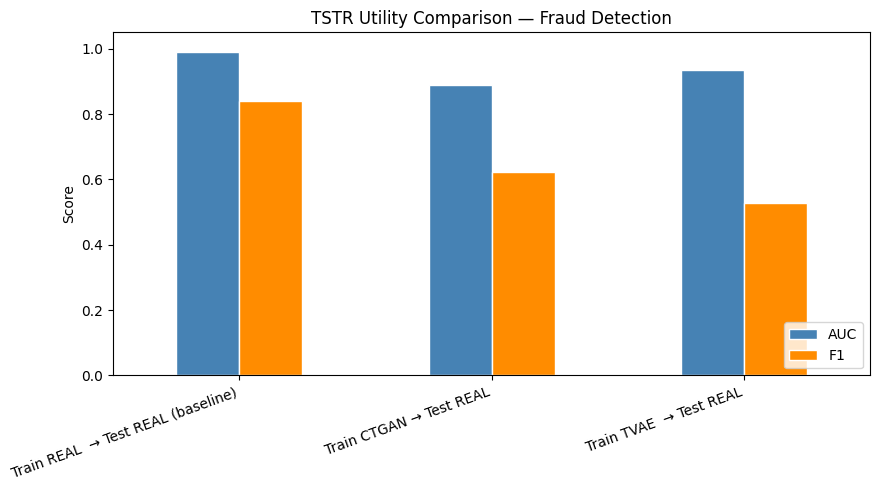

In [37]:
# ── Summary table ─────────────────────────────────────────────────────────────
utility_df = pd.DataFrame({
    'AUC': [auc_real,  auc_ctgan,  auc_tvae],
    'F1' : [f1_real,   f1_ctgan,   f1_tvae]
}, index=['Train REAL  → Test REAL (baseline)',
          'Train CTGAN → Test REAL',
          'Train TVAE  → Test REAL'])

print(utility_df.to_string())

# Bar chart
utility_df.plot(kind='bar', figsize=(9, 5), color=['steelblue', 'darkorange'],
                ylim=(0, 1.05), edgecolor='white')
plt.title('TSTR Utility Comparison — Fraud Detection')
plt.ylabel('Score')
plt.xticks(rotation=20, ha='right')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

Privacy — Nearest-Neighbour Distance Heuristic

Nearest-neighbour distance statistics (higher = less memorisation risk):
       CTGAN_NN_dist  TVAE_NN_dist
count   5.000000e+03   5000.000000
mean    3.984100e-03      0.000471
std     1.147473e-02      0.005288
min     4.616242e-09      0.000000
25%     2.823454e-05      0.000000
50%     9.136906e-05      0.000053
75%     7.385558e-04      0.000160
max     2.042706e-01      0.328371


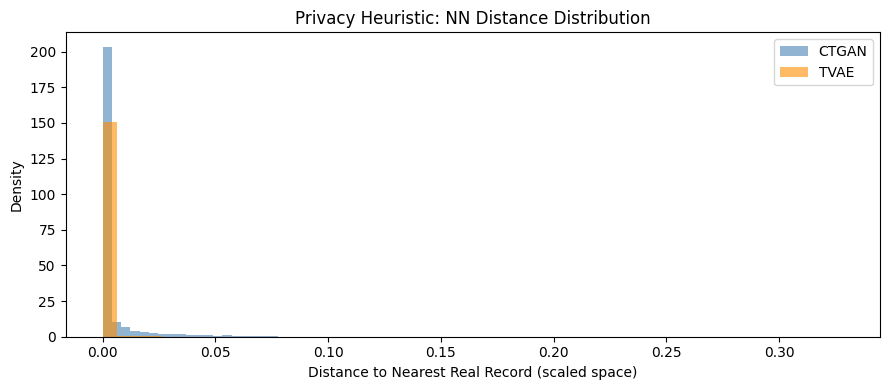

In [38]:
real_num_scaled  = scaler.transform(real_all[num_cols].sample(5000, random_state=42))
ctgan_num_scaled = scaler.transform(synthetic_ctgan[num_cols].sample(min(5000, N_SYNTH), random_state=42))
tvae_num_scaled  = scaler.transform(synthetic_tvae[num_cols].sample(min(5000, N_SYNTH), random_state=42))

nn = NearestNeighbors(n_neighbors=1, n_jobs=-1)
nn.fit(real_num_scaled)

dist_ctgan = nn.kneighbors(ctgan_num_scaled)[0].flatten()
dist_tvae  = nn.kneighbors(tvae_num_scaled)[0].flatten()

privacy_df = pd.DataFrame({'CTGAN_NN_dist': dist_ctgan, 'TVAE_NN_dist': dist_tvae})
print('Nearest-neighbour distance statistics (higher = less memorisation risk):')
print(privacy_df.describe().to_string())

# Distribution plot
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(dist_ctgan, bins=50, alpha=0.6, color='steelblue',   label='CTGAN', density=True)
ax.hist(dist_tvae,  bins=50, alpha=0.6, color='darkorange',  label='TVAE',  density=True)
ax.set_xlabel('Distance to Nearest Real Record (scaled space)')
ax.set_ylabel('Density')
ax.set_title('Privacy Heuristic: NN Distance Distribution')
ax.legend()
plt.tight_layout()
plt.show()

Overall Quality Summary

In [39]:
print('=' * 60)
print('SYNTHETIC DATA QUALITY REPORT — fraud_transactions.csv')
print('=' * 60)

print('\n── FIDELITY (KS test — lower is better) ──────────────────')
print(f'  Mean KS  CTGAN : {ks_ctgan["ks_stat"].mean():.4f}')
print(f'  Mean KS  TVAE  : {ks_tvae["ks_stat"].mean():.4f}')
better_fidelity = 'CTGAN' if ks_ctgan['ks_stat'].mean() < ks_tvae['ks_stat'].mean() else 'TVAE'
print(f'  → Better fidelity: {better_fidelity}')

print('\n── UTILITY (TSTR AUC — closer to TRTR baseline is better) ─')
print(f'  Baseline TRTR  AUC : {auc_real:.4f}')
print(f'  CTGAN TSTR AUC     : {auc_ctgan:.4f}  (gap: {abs(auc_real - auc_ctgan):.4f})')
print(f'  TVAE  TSTR AUC     : {auc_tvae:.4f}  (gap: {abs(auc_real - auc_tvae):.4f})')
better_utility = 'CTGAN' if abs(auc_real - auc_ctgan) < abs(auc_real - auc_tvae) else 'TVAE'
print(f'  → Better utility: {better_utility}')

print('\n── PRIVACY (NN distance — higher is better) ───────────────')
print(f'  Median NN dist CTGAN : {np.median(dist_ctgan):.4f}')
print(f'  Median NN dist TVAE  : {np.median(dist_tvae):.4f}')
better_privacy = 'CTGAN' if np.median(dist_ctgan) > np.median(dist_tvae) else 'TVAE'
print(f'  → Better privacy (less memorisation): {better_privacy}')

print('\n' + '=' * 60)
print('NOTE: No single synthesiser dominates on all three pillars.')
print('Choose based on your downstream use case.')
print('=' * 60)

SYNTHETIC DATA QUALITY REPORT — fraud_transactions.csv

── FIDELITY (KS test — lower is better) ──────────────────
  Mean KS  CTGAN : 0.0998
  Mean KS  TVAE  : 0.0486
  → Better fidelity: TVAE

── UTILITY (TSTR AUC — closer to TRTR baseline is better) ─
  Baseline TRTR  AUC : 0.9905
  CTGAN TSTR AUC     : 0.8880  (gap: 0.1025)
  TVAE  TSTR AUC     : 0.9353  (gap: 0.0552)
  → Better utility: TVAE

── PRIVACY (NN distance — higher is better) ───────────────
  Median NN dist CTGAN : 0.0001
  Median NN dist TVAE  : 0.0001
  → Better privacy (less memorisation): CTGAN

NOTE: No single synthesiser dominates on all three pillars.
Choose based on your downstream use case.
